<a href="https://colab.research.google.com/github/NazHub1993/Deep-Learning/blob/main/Tensorflow_Dataset_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

In [2]:
daily_sales_numbers = [21, 22, -108, 31, -1, 32, 34,31]

tf_dataset=tf.data.Dataset.from_tensor_slices(daily_sales_numbers)
tf_dataset


<_TensorSliceDataset element_spec=TensorSpec(shape=(), dtype=tf.int32, name=None)>

In [3]:
for sales in tf_dataset:
  print(sales.numpy())

21
22
-108
31
-1
32
34
31


In [4]:
for sales in tf_dataset.as_numpy_iterator():
  print(sales)

21
22
-108
31
-1
32
34
31


In [5]:
for sales in tf_dataset.take(3):
  print(sales.numpy())

21
22
-108


#Filter

In [6]:
tf_dataset=tf_dataset.filter(lambda x: x>0)
for sales in tf_dataset.as_numpy_iterator():
  print(sales)


21
22
31
32
34
31


#Map

In [9]:
tf_dataset=tf_dataset.map(lambda y: y*72)
for sales in tf_dataset.as_numpy_iterator():
  print(sales)


108864
114048
160704
165888
176256
160704


In [11]:
tf_dataset=tf_dataset.shuffle(2)

#Batch

In [12]:
for sales_batch in tf_dataset.batch(3):
  print(sales_batch.numpy())

[114048 108864 165888]
[176256 160704 160704]


#To perform all the operations at once

In [15]:
tf_dataset=tf.data.Dataset.from_tensor_slices(daily_sales_numbers)
tf_dataset=tf_dataset.filter(lambda x: x>0).map(lambda y: y*72).shuffle(2).batch(2)


for sales in tf_dataset.as_numpy_iterator():
  print(sales)

[1584 2232]
[1512 2448]
[2232 2304]


#Let's apply this on cat_dog dataset

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
images_ds = tf.data.Dataset.list_files(
    '/content/drive/MyDrive/Cat_and_Dog_images/*/*',
    shuffle=False
)

In [22]:
img_cnt=len(images_ds)

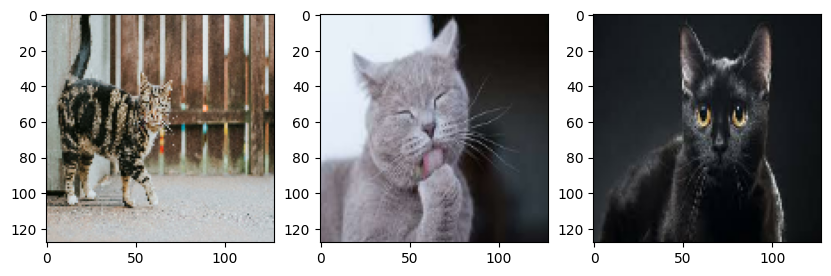

In [21]:
import matplotlib.pyplot as plt
import tensorflow as tf

# Define a function to load and preprocess an image
def load_and_preprocess_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3) # Assuming JPEG, specify channels=3 for RGB
    image = tf.image.resize(image, [128, 128]) # Resize to a common size
    return image

# Apply the function to the dataset
processed_images_ds = images_ds.map(load_and_preprocess_image)

# Take the first 3 processed images and display them
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
for i, image_tensor in enumerate(processed_images_ds.take(3)):
    axes[i].imshow(image_tensor.numpy().astype("uint8")) # Convert to numpy and then to uint8

plt.show()

In [25]:
images_ds=images_ds.shuffle(20)
for file in images_ds.take(3):
  print(file.numpy())

b'/content/drive/MyDrive/Cat_and_Dog_images/cats/cat_102.jpg'
b'/content/drive/MyDrive/Cat_and_Dog_images/cats/cat_129.jpg'
b'/content/drive/MyDrive/Cat_and_Dog_images/cats/cat_141.jpg'


In [26]:
train_size=int(img_cnt*0.8)

train_ds=images_ds.take(train_size)
test_ds=images_ds.skip(train_size)

#Now how to get the label from file path

In [27]:
def get_label(file_path):
  import os
  parts=tf.strings.split(file_path,os.path.sep)
  return parts[-2]

In [28]:
get_label('/content/drive/MyDrive/Cat_and_Dog_images/cats/cat_102.jpg')

<tf.Tensor: shape=(), dtype=string, numpy=b'cats'>

In [29]:
def process_all(file_path):
  label=get_label(file_path)
  img=tf.io.read_file(file_path)
  img=tf.image.decode_jpeg(img)
  img=tf.image.resize(img,[128,128])
  return img,label

Text(0.5, 1.0, "b'cats'")

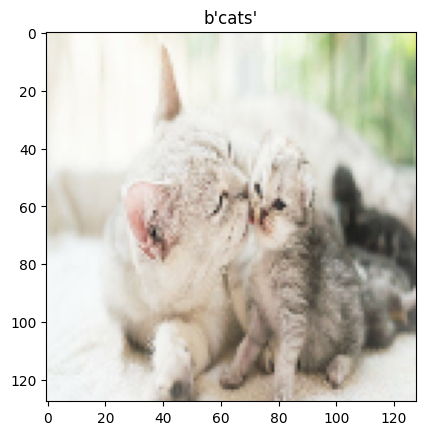

In [34]:
img,label=process_all('/content/drive/MyDrive/Cat_and_Dog_images/cats/cat_102.jpg')
plt.imshow(img.numpy().astype('uint8'))
plt.title(label.numpy())

In [35]:
train_ds=train_ds.map(process_all)
test_ds=test_ds.map(process_all)

In [38]:
for data in train_ds.take(1):
  print(data)

(<tf.Tensor: shape=(128, 128, 3), dtype=float32, numpy=
array([[[241.77441, 237.77441, 228.77441],
        [236.     , 232.5625 , 218.875  ],
        [237.     , 234.     , 215.     ],
        ...,
        [233.94043, 245.     , 184.88086],
        [232.     , 242.04688, 168.90625],
        [226.1875 , 239.1875 , 149.5625 ]],

       [[243.     , 239.     , 230.     ],
        [238.     , 234.5625 , 220.875  ],
        [238.80566, 235.80566, 218.80566],
        ...,
        [228.14062, 240.14062, 174.4043 ],
        [230.0791 , 240.0791 , 170.2041 ],
        [227.     , 239.     , 153.375  ]],

       [[243.     , 239.     , 230.     ],
        [237.86816, 234.43066, 220.74316],
        [238.76562, 234.76562, 222.76562],
        ...,
        [228.23438, 241.23438, 171.13867],
        [228.13184, 239.13184, 161.60059],
        [225.1875 , 238.80957, 145.03125]],

       ...,

       [[240.90918, 244.90918, 245.90918],
        [242.43066, 246.43066, 247.43066],
        [243.0332 , 247.03

In [39]:
def scale(img,label):
  return img/255, label

In [40]:
train_ds=train_ds.map(scale)
test_ds=test_ds.map(scale)